In [15]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from torch.nn import init
import math

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
@dataclass
class Config:
    vocab_size: int = 65
    d_model: int = 128
    n_heads: int = 8
    n_kv_heads: int = 2
    n_layers: int = 4
    n_experts: int = 8
    top_k: int = 2
    dropout: float = 0.1
    block_size: int = 128
    rope_theta: float = 10000.0
    rms_eps: float = 1e-5

In [18]:
class Expert(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ffwd = nn.Sequential(
        nn.Linear(config.d_model, 4*config.d_model),
        nn.ReLU(),
        nn.Linear(4*config.d_model, config.d_model),
        nn.Dropout(config.dropout)
    )

  def forward(self, x):
    # x = (B*T, C)
    return self.ffwd(x) # (B*T, C)

In [19]:
class NoisyTopKRouter(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.top_k = config.top_k
    self.linear = nn.Linear(config.d_model, config.n_experts) # [routing matrix]
    self.noise_linear = nn.Linear(config.d_model, config.n_experts) # predicts how much noise should be added to each expert (can be negative)

  def forward(self, x):
    # x = (B, T, C) [output from the GQA block]
    logits = self.linear(x) # (B, T, C) @ (C, n_experts) = (B, T, n_experts) [expert selector matrix]
    noise_scale = self.noise_linear(x) # (B, T, n_experts)

    # softplus [smooth ReLU]; noise * noise_scale
    noise = torch.randn_like(logits) * F.softplus(noise_scale) # (B, T, n_experts)
    noisy_logits = logits + noise # (B, T, n_experts)

    top_k_logits, top_k_indices = noisy_logits.topk(self.top_k, dim=-1) # (B, T, top_k), (B, T, top_k)
    zeros_matrix = torch.full_like(logits, float("-inf")) # (B, T, n_experts)
    sparse_logits = zeros_matrix.scatter(dim=-1, index=top_k_indices, src=top_k_logits) # (B, T, n_experts)
    router_output = F.softmax(sparse_logits, dim=-1) # (B, T, n_experts)
    return router_output, top_k_indices # (B, T, n_experts), (B, T, top_k)

In [20]:
class SparseMoE(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.router = NoisyTopKRouter(config)
    self.experts = nn.ModuleList([Expert(config) for _ in range(config.n_experts)])
    self.top_k = config.top_k

  def forward(self, x):
    # x = (B, T, C)
    router_output, top_k_indices = self.router(x) # (B, T, n_experts), (B, T, top_k)
    final_output = torch.zeros_like(x) # (B, T, C)

    flat_x = x.view(-1, x.size(-1)) # (B*T, C)
    flat_router_output = router_output.view(-1, router_output.size(-1)) # (B*T, n_experts)

    # process each expert in parallel
    for i, expert in enumerate(self.experts):
      # [boolean mask]
      expert_mask = (top_k_indices == i).any(dim=-1) # (B, T)
      flat_expert_mask = expert_mask.view(-1) # (B*T)

      if flat_expert_mask.any():
        expert_input = flat_x[flat_expert_mask] # (<B*T, C) [selected tokens]
        expert_output = expert(expert_input) # (<B*T, C)

        gating_scores = flat_router_output[flat_expert_mask, i].unsqueeze(1) # (<B*T, 1)
        weighted_output = expert_output * gating_scores # (<B*T, d_model)
        final_output[expert_mask] += weighted_output.squeeze(1) # (B, T, C)
    return final_output # (B, T, C)

In [21]:
class RMSNorm(nn.Module):
  def __init__(self, d_model, eps=1e-5):
    super().__init__()
    self.eps = eps
    self.gamma = nn.Parameter(torch.ones(d_model))


  def forward(self, x):
    # x (B, T, C)
    out = (x**2).mean(dim=-1, keepdim=True) # (B, T, 1)
    out = 1 / torch.sqrt(out + self.eps) # (B, T, 1)
    out = x * out # (B, T, C)
    out = out * self.gamma # (B, T, C)
    return out

class SwiGLUExpert(nn.Module):
  def __init__(self, config):
    super().__init__()
    hidden = 4 * config.d_model
    self.w1 = nn.Linear(config.d_model, hidden, bias=False)
    self.w3 = nn.Linear(config.d_model, hidden, bias=False)
    self.w2 = nn.Linear(hidden, config.d_model, bias=False)
    self.dropout = nn.Dropout(config.dropout)

  def forward(self, x):
    return self.dropout(self.w2(F.silu(self.w1(x)) * self.w3(x)))

In [22]:
# Rotary Position Embeddings (RoPE)
def build_rope_cache(head_size, block_size, theta=10000.0, device="cpu"):
  freqs = 1.0 / (theta ** (torch.arange(0, head_size, 2, device=device).float() / head_size))
  t = torch.arange(block_size, device=device).float()
  freqs = torch.outer(t, freqs)
  cos, sin = freqs.cos(), freqs.sin()
  return cos, sin

def apply_rope(x, cos, sin):
  B, H, T, head_size = x.shape
  x1, x2 = x[..., ::2], x[..., 1::2] # (B, H, T, head_size//2)
  cos = cos[:T].view(1, 1, T, head_size//2)
  sin = sin[:T].view(1, 1, T, head_size//2)
  rot_x1 = x1 * cos - x2 * sin
  rot_x2 = x1 * sin + x2 * cos
  out = torch.stack([rot_x1, rot_x2], dim=-1).reshape(B, H, T, head_size)
  return out

In [23]:
class GroupedQueryAttention(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.d_model = config.d_model
    self.n_heads = config.n_heads
    self.n_kv_heads = config.n_kv_heads
    self.head_size = self.d_model // self.n_heads
    self.n_rep = self.n_heads // self.n_kv_heads
    self.W_q = nn.Linear(config.d_model, config.d_model)
    self.W_k = nn.Linear(config.d_model, self.head_size * config.n_kv_heads)
    self.W_v = nn.Linear(config.d_model, self.head_size * config.n_kv_heads)
    self.W_o = nn.Linear(config.d_model, config.d_model)
    self.dropout = nn.Dropout(config.dropout)

  def forward(self, x, rope_cos, rope_sin, mask):
    B, T, C = x.size()
    q = self.W_q(x).view(B, T, self.n_heads, self.head_size).transpose(1, 2) # (B, n_heads, T, D)
    k = self.W_k(x).view(B, T, self.n_kv_heads, self.head_size).transpose(1, 2) # (B, n_kv_heads, T, D)
    v = self.W_v(x).view(B, T, self.n_kv_heads, self.head_size).transpose(1, 2) # (B, n_kv_heads, T, D)

    q = apply_rope(q, rope_cos, rope_sin)
    k = apply_rope(k, rope_cos, rope_sin)

    k = k.repeat_interleave(self.n_rep, dim=1) # (B, n_heads, T, D)
    v = v.repeat_interleave(self.n_rep, dim=1) # (B, n_heads, T, D)

    attn_scores = q @ k.transpose(-1, -2) / math.sqrt(self.head_size) # (B, n_heads, T, T)
    attn_scores = attn_scores.masked_fill(mask == 0, float("-inf")) # (B, n_heads, T, T)
    attn_probs = self.dropout(F.softmax(attn_scores, dim=-1)) # (B, n_heads, T, T)
    out = attn_probs @ v # (B, n_heads, T, D)

    out = out.transpose(1, 2).contiguous().view(B, T, self.n_heads * self.head_size) # (B, T, C)
    out = self.W_o(out) # (B, T, C)
    return out

In [24]:
class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.attn = GroupedQueryAttention(config)
    self.smoe = SparseMoE(config)
    self.norm1 = RMSNorm(config.d_model, config.rms_eps)
    self.norm2 = RMSNorm(config.d_model, config.rms_eps)

  def forward(self, x, rope_cos, rope_sin, mask):
    x = x + self.attn(self.norm1(x), rope_cos, rope_sin, mask)
    x = x + self.smoe(self.norm2(x))
    return x

In [25]:
class SparseMoELanguageModel(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.config = config
    self.token_embedding_table = nn.Embedding(config.vocab_size, config.d_model)
    self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layers)])
    self.norm = RMSNorm(config.d_model, config.rms_eps)
    self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)

    head_size = config.d_model // config.n_heads
    cos, sin = build_rope_cache(head_size, config.block_size, config.rope_theta, device)
    self.register_buffer("rope_cos", cos, persistent=False)
    self.register_buffer("rope_sin", sin, persistent=False)
    self.register_buffer(
        "causal_mask",
        torch.tril(torch.ones(config.block_size, config.block_size)).view(
            1, 1, config.block_size, config.block_size
        ),
    )

  def forward(self, idx, targets=None):
    B, T = idx.shape
    x = self.token_embedding_table(idx)  # (B, T, C)

    mask = self.causal_mask[:, :, :T, :T]
    for block in self.blocks:
        x = block(x, self.rope_cos, self.rope_sin, mask)
    x = self.norm(x)
    logits = self.lm_head(x)

    if targets is None:
        loss = None
    else:
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.view(B*T, V), targets.view(B*T))

    return logits, loss

  @torch.no_grad()
  def generate(self, idx, max_new_tokens):
    self.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -self.config.block_size:]
        logits, _ = self(idx_cond)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    self.train()
    return idx

In [26]:
# training parameters
batch_size = 32
block_size = 128
max_iters = 9000
eval_interval = 300
eval_iters = 50
learning_rate = 3e-4

In [27]:
torch.manual_seed(1337)

with open("input.txt", "r", encoding="utf-8") as f:
  text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split):
  data = train_data if split=="train" else val_data
  ix = torch.randint(len(data) - block_size, (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  x, y = x.to(device), y.to(device)
  return x, y


In [28]:
def kaiming_init_weights(m):
  if isinstance(m, (nn.Linear)):
    init.kaiming_normal_(m.weight)

In [29]:
config = Config(vocab_size=vocab_size)
model = SparseMoELanguageModel(config)
model.apply(kaiming_init_weights)

SparseMoELanguageModel(
  (token_embedding_table): Embedding(98, 128)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (attn): GroupedQueryAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=32, bias=True)
        (W_v): Linear(in_features=128, out_features=32, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (smoe): SparseMoE(
        (router): NoisyTopKRouter(
          (linear): Linear(in_features=128, out_features=8, bias=True)
          (noise_linear): Linear(in_features=128, out_features=8, bias=True)
        )
        (experts): ModuleList(
          (0-7): 8 x Expert(
            (ffwd): Sequential(
              (0): Linear(in_features=128, out_features=512, bias=True)
              (1): ReLU()
              (2): Linear(in_features=512, out_features=128, bias=True)
              (3): Dropout(p=0.1, inplac

In [30]:
m = model.to(device)
print(sum(p.numel() for p in m.parameters())/1e6, "M parameters")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

4.4144 M parameters


In [31]:
@torch.no_grad()
def estimate_loss():
  out = {}
  acc = {}
  model.eval()
  for split in ["train", "val"]:
    losses = torch.zeros(eval_iters)
    accs = torch.zeros(eval_iters)
    for k in range(eval_iters):
      X, Y = get_batch(split)
      logits, loss = model(X, Y)
      losses[k] = loss.item()
      accs[k] = (logits.argmax(dim=-1) == Y).float().mean().item()
    out[split] = losses.mean()
    acc[split] = accs.mean()
  model.train()
  return out, acc

In [32]:
history = {"iter": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for iter in range(max_iters):
  if iter % eval_interval == 0 or iter == max_iters-1:
    losses, accs = estimate_loss()
    print(f'step {iter}: train loss {losses["train"]:.4f}, val loss {losses["val"]:.4f}, train acc {accs["train"]:.4f}, val acc {accs["val"]:.4f}')
    history["iter"].append(iter)
    history["train_loss"].append(losses["train"].item())
    history["val_loss"].append(losses["val"].item())
    history["train_acc"].append(accs["train"].item())
    history["val_acc"].append(accs["val"].item())
  xb, yb = get_batch("train")

  logits, loss = model(xb, yb)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

step 0: train loss 5.2956, val loss 5.2857, train acc 0.0190, val acc 0.0194
step 300: train loss 1.8553, val loss 1.8418, train acc 0.4479, val acc 0.4521
step 600: train loss 1.4935, val loss 1.4825, train acc 0.5504, val acc 0.5543
step 900: train loss 1.3361, val loss 1.3234, train acc 0.5929, val acc 0.5973
step 1200: train loss 1.2526, val loss 1.2527, train acc 0.6164, val acc 0.6179
step 1500: train loss 1.2045, val loss 1.1870, train acc 0.6283, val acc 0.6342
step 1800: train loss 1.1599, val loss 1.1483, train acc 0.6402, val acc 0.6459
step 2100: train loss 1.1183, val loss 1.1243, train acc 0.6517, val acc 0.6519
step 2400: train loss 1.0980, val loss 1.0933, train acc 0.6578, val acc 0.6575
step 2700: train loss 1.0783, val loss 1.0665, train acc 0.6641, val acc 0.6681
step 3000: train loss 1.0544, val loss 1.0523, train acc 0.6694, val acc 0.6707
step 3300: train loss 1.0366, val loss 1.0403, train acc 0.6752, val acc 0.6749
step 3600: train loss 1.0243, val loss 1.0291,

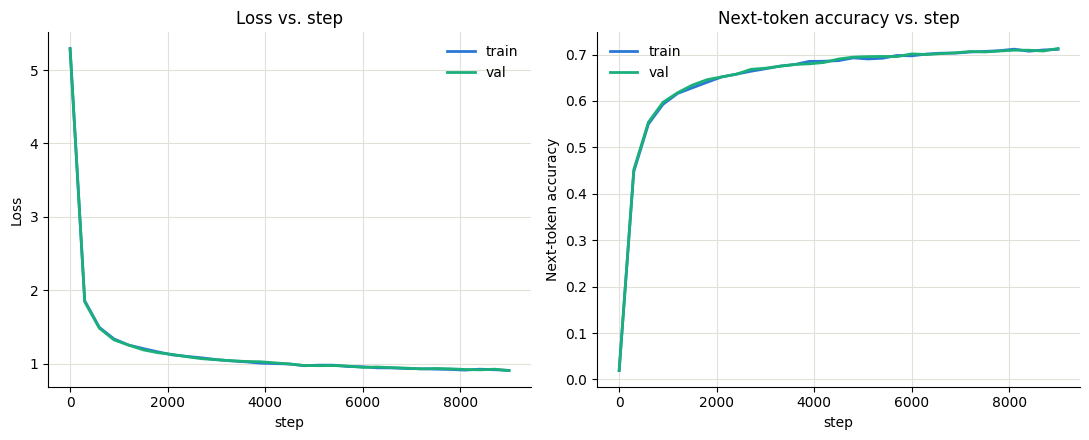

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

panels = [
    ("train_loss", "val_loss", "Loss"),
    ("train_acc", "val_acc", "Next-token accuracy"),
]

for ax, (train_key, val_key, title) in zip(axes, panels):
    ax.plot(history["iter"], history[train_key], color="#2a78d6", linewidth=2, label="train")
    ax.plot(history["iter"], history[val_key], color="#1baf7a", linewidth=2, label="val")
    ax.set_xlabel("step")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs. step")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [37]:
context = torch.zeros((1,1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=100)[0].tolist()))


<|endoftext|>

Once upon a time, there was a dog named Timmy. He was very excited to spend his frien
